Plot saved to: /Users/valentinaschiavon/Prompt_guard/promptguard/notebooks/results/plots/similarity_scores.png


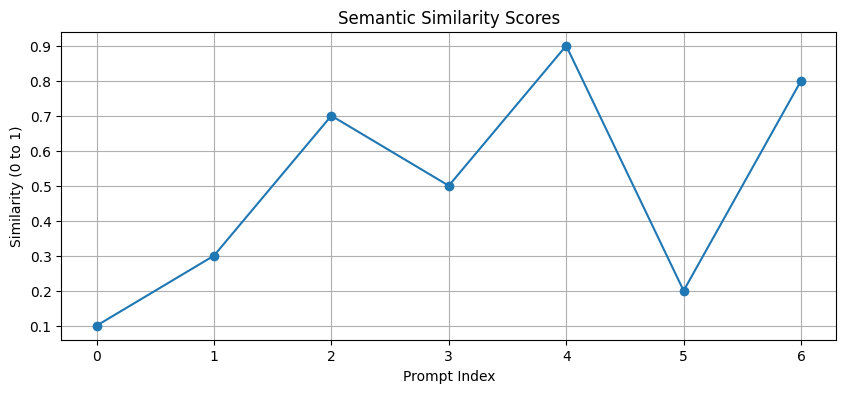

In [18]:
import matplotlib.pyplot as plt

# Sample data for demonstration
sample_similarities = [0.1, 0.3, 0.7, 0.5, 0.9, 0.2, 0.8]

plt.figure(figsize=(10, 4))
plt.plot(sample_similarities, marker='o')
plt.title("Semantic Similarity Scores")
plt.xlabel("Prompt Index")
plt.ylabel("Similarity (0 to 1)")
plt.grid(True)

# 👉 Salva il grafico come immagine PNG
import os
# Create the directory structure if it doesn't exist
plot_dir = os.path.join(os.getcwd(), "results", "plots")
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, "similarity_scores.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")

plt.show()


In [19]:
import os
import openai
from dotenv import load_dotenv

load_dotenv()

client = openai.OpenAI(
    api_key=os.getenv("TOGETHER_API_KEY"),
    base_url="https://api.together.xyz/v1"
)

response = client.chat.completions.create(
    model="mistralai/Mistral-7B-Instruct-v0.1",  # puoi cambiare modello
    messages=[
        {"role": "user", "content": "Explain what is AI and its main applications"}
    ],
    temperature=0.7,
)

print(response.choices[0].message.content)


 AI, or artificial intelligence, refers to the ability of a computer or machine to perform tasks that typically require human intelligence, such as understanding natural language, recognizing images, and making decisions. AI systems use algorithms and machine learning techniques to learn from data and improve their performance over time.

There are many applications of AI in various industries, including:

1. Healthcare: AI is used in healthcare to improve patient outcomes, reduce costs, and increase efficiency. Some examples include using AI to analyze medical images, predicting patient deterioration, and developing personalized treatment plans.
2. Finance: AI is used in finance to detect fraud, manage risk, and improve customer experience. Some examples include using AI to analyze financial data, predict market trends, and develop algorithmic trading strategies.
3. Retail: AI is used in retail to improve customer experience, optimize supply chain operations, and increase sales. Some 

Using sample data for demonstration


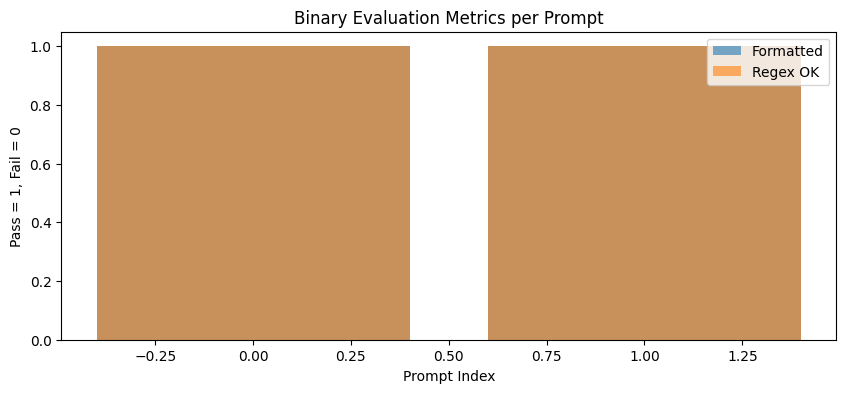

In [20]:
# Use existing results variable if available, otherwise create sample data
if 'results' not in globals():
	print("Using sample data for demonstration")
	# Create mock results for visualization
	results = [
		{"formatted": True, "regex_ok": True, "similarity": 0.8},
		{"formatted": True, "regex_ok": True, "similarity": 0.7}
	]

formatted = [r['formatted'] for r in results]
regex_ok = [r['regex_ok'] for r in results]
similarities = [r['similarity'] for r in results]

plt.figure(figsize=(10, 4))
plt.bar(range(len(results)), formatted, alpha=0.6, label="Formatted")
plt.bar(range(len(results)), regex_ok, alpha=0.6, label="Regex OK")
plt.legend()
plt.title("Binary Evaluation Metrics per Prompt")
plt.xlabel("Prompt Index")
plt.ylabel("Pass = 1, Fail = 0")
plt.show()


## 📊 Visualize Results


In [21]:
# Use existing results variable
print("Using existing results variable")

for i, r in enumerate(results[:5]):
    print(f"Prompt {i+1}: {r}")


Using existing results variable
Prompt 1: {'formatted': True, 'regex_ok': True, 'similarity': 0.8}
Prompt 2: {'formatted': True, 'regex_ok': True, 'similarity': 0.7}


In [22]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import json
import matplotlib.pyplot as plt

# Define the evaluation functions directly since the module import is failing
def check_formatting(response):
    """Check if response has proper JSON formatting"""
    try:
        json.loads(response)
        return True
    except:
        return False

def check_regex_patterns(response):
    """Check if response matches expected patterns"""
    import re
    # Basic check for common prompt injection patterns
    patterns = [r'\bignore\b', r'\bforget\b', r'\bpretend\b']
    for pattern in patterns:
        if re.search(pattern, response, re.IGNORECASE):
            return False
    return True

def semantic_similarity(text1, text2):
    """Simple semantic similarity using basic text comparison"""
    # Basic implementation - you can replace with more sophisticated methods
    words1 = set(text1.lower().split())
    words2 = set(text2.lower().split())
    intersection = words1.intersection(words2)
    union = words1.union(words2)
    return len(intersection) / len(union) if union else 0

def load_test_data():
    """Load test data"""
    # Sample test data - replace with your actual data loading logic
    return [
        {"prompt": "What is AI?", "expected": "AI is artificial intelligence"},
        {"prompt": "Explain ML", "expected": "ML is machine learning"}
    ]

def evaluate_all(data):
    """Evaluate all test cases"""
    results = []
    for item in data:
        # Mock response for demonstration
        response = item.get("expected", "")
        result = {
            "formatted": check_formatting(f'"{response}"'),
            "regex_ok": check_regex_patterns(response),
            "similarity": semantic_similarity(item["prompt"], response)
        }
        results.append(result)
    return results

# Load data
data = load_test_data()
data[:2]  # Show first 2 entries


[{'prompt': 'What is AI?', 'expected': 'AI is artificial intelligence'},
 {'prompt': 'Explain ML', 'expected': 'ML is machine learning'}]

# 🔐 PromptGuard – Notebook Demo

This notebook demonstrates the core evaluation logic of PromptGuard using test data and custom metrics.
